# Caso 1 — Tokyo Gallery: Evaluación de VAN con Simulación de Monte Carlo

**Tarea 8 — Minería de Datos | Lead University**

---

## Contexto del problema

Se evalúa si conviene vender un nuevo producto en la plaza comercial **Tokyo Gallery**.

| Parámetro | Valor |
|-----------|-------|
| Duración del proyecto | 5 años |
| Ventas unitarias anuales | 1.000 unidades (fijas) |
| Costos operativos fijos | $3.000 / año (fijos) |
| Inversión inicial | $1.500 |
| Tasa de descuento | 10% anual |
| Sin impuestos | — |

**Variable incierta:** el precio por unidad, que cada año puede tomar uno de tres valores:

| Precio | Probabilidad |
|--------|-------------|
| $2,75  | 25% |
| $3,50  | 50% |
| $4,25  | 25% |

El precio varía de forma independiente cada año.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '..')

from scripts import MonteCarloSimulator

np.random.seed(42)

---

## 1. Modelo determinístico (precio fijo = precio esperado)

### 1.1 Modelo matemático

$$\text{Flujo de caja}_t = \text{Precio}_t \times \text{Unidades} - \text{Costos fijos}$$

$$\text{VAN} = -\text{Inversión} + \sum_{t=1}^{5} \frac{\text{Flujo de caja}_t}{(1 + r)^t}$$

Primero calculamos el VAN usando el **precio esperado**:  
$E[\text{Precio}] = 0.25 \times 2.75 + 0.50 \times 3.50 + 0.25 \times 4.25 = 3.50$

In [35]:
# Parámetros fijos del proyecto
unidades      = 1_000
costos_fijos  = 3_000
inversion     = 1_500
tasa          = 0.10
años          = 5

# Distribución discreta del precio
precios_posibles  = [2.75, 3.50, 4.25]
probabilidades    = [0.25, 0.50, 0.25]

# Precio esperado
precio_esperado = sum(p * pr for p, pr in zip(precios_posibles, probabilidades))
print(f"Precio esperado: ${precio_esperado:.2f}")

# Flujos de caja con precio fijo = precio esperado
flujos = [(precio_esperado * unidades - costos_fijos) for _ in range(años)]

# VAN determinístico
van_det = -inversion + sum(fc / (1 + tasa)**t for t, fc in enumerate(flujos, start=1))

print("\nFlujos de caja anuales (precio esperado):")
for t, fc in enumerate(flujos, start=1):
    print(f"  Año {t}: ${fc:,.2f}")
print(f"\nVAN determinístico (precio esperado $3.50): ${van_det:,.2f}")

Precio esperado: $3.50

Flujos de caja anuales (precio esperado):
  Año 1: $500.00
  Año 2: $500.00
  Año 3: $500.00
  Año 4: $500.00
  Año 5: $500.00

VAN determinístico (precio esperado $3.50): $395.39


### Interpretación — Modelo determinístico

Con el precio esperado de **$3.50**, el flujo anual es $500 y el **VAN determinístico es $395.39** — positivo, lo que sugiere que el proyecto crea valor.

Sin embargo, este resultado asume un precio fijo durante los 5 años. El escenario más desfavorable (precio $2.75 siempre) produce un flujo anual de **-$250** y un **VAN de -$2,447.70**, lo que confirma que hay riesgo real si los precios son bajos de forma persistente.

Para cuantificar esa probabilidad es necesaria la simulación de Monte Carlo.

---

## 2. Simulación de Monte Carlo — flujo de caja anual

Primero simulamos el **flujo de caja de un año tipo**, que es la variable resultado directa antes de calcular el VAN. Esto sigue exactamente el esquema del notebook de clase: una variable incierta (precio) → n muestras → resultado (flujo).

In [36]:
n_sim = 500

# Sección 4 — Generar números aleatorios
precio_sim = np.random.choice(precios_posibles, size=n_sim, p=probabilidades)
print("precio_sim → primeras 5:", precio_sim[:5])

# Sección 5 — Ejecutar simulaciones: flujo anual = precio × unidades − costos_fijos
flujo_sim   = precio_sim * unidades - costos_fijos
ingresos_s  = precio_sim * unidades

print(f"\nSimulaciones: {n_sim}")
print(f"Primeros flujos: {flujo_sim[:5]}")

precio_sim → primeras 5: [3.5  4.25 3.5  3.5  2.75]

Simulaciones: 500
Primeros flujos: [ 500. 1250.  500.  500. -250.]


=== Resumen: flujo ===
  Media:                       501.50
  Desviación estándar:         541.87
  Mínimo:                     -250.00
  Máximo:                    1,250.00
  Percentil  5%:              -250.00
  Percentil 50%:               500.00
  Percentil 95%:             1,250.00
  P(flujo < 0):             26.0%


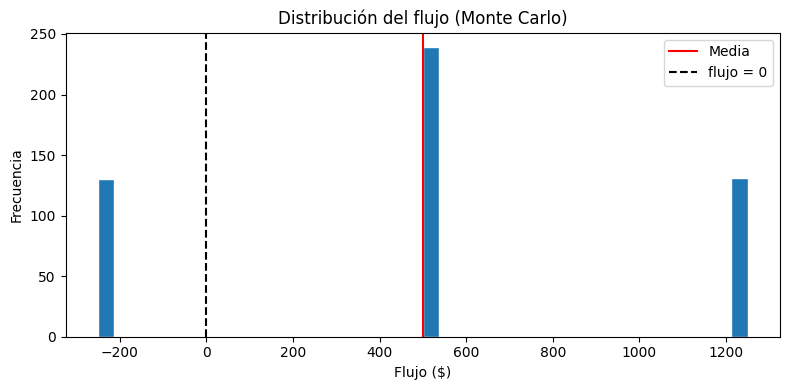

In [37]:
# Sección 6 — Analizar resultados del flujo anual
# seed=None para no reiniciar el estado aleatorio ya fijado al inicio del notebook
sim_flujo = MonteCarloSimulator(n=n_sim, seed=None)
sim_flujo.muestras["precio"] = precio_sim
sim_flujo.agregar_resultado("flujo", flujo_sim)
sim_flujo.agregar_resultado("ingresos", precio_sim * unidades)

sim_flujo.resumen("flujo")

# Histograma — igual al gráfico del notebook de clase
sim_flujo.plot_histograma("flujo", xlabel="Flujo ($)", titulo="Distribución del flujo (Monte Carlo)")

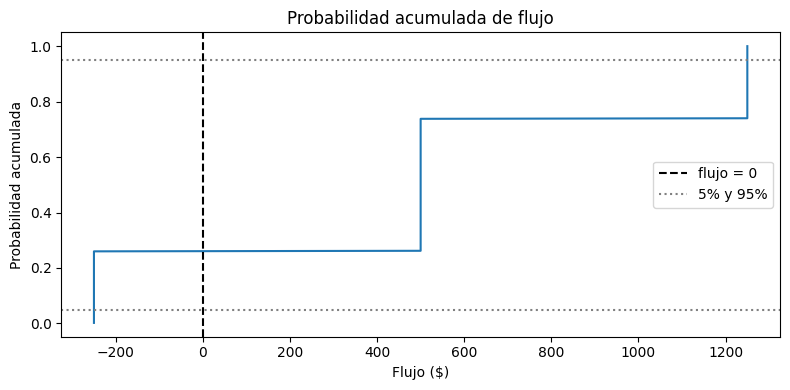

Correlación con flujo:
  precio: 1.000


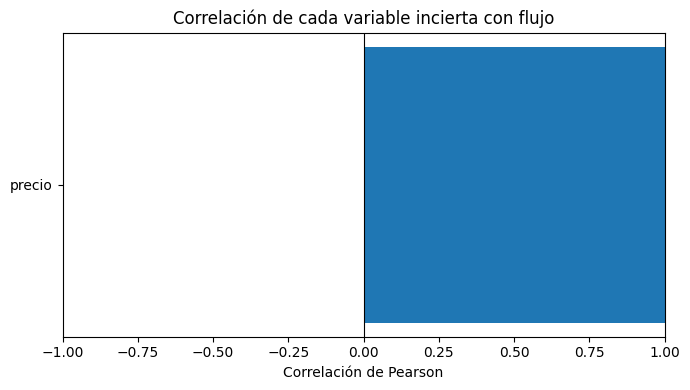


Impacto de precio sobre flujo:
  Bajo: 235.77
  Medio: nan
  Alto: 1,250.00
  Impacto Bajo → Medio: nan
  Impacto Medio → Alto: nan


h:\Mi unidad\Universidad\Ulead\Repos\curso_mineria_de_datos\Practicas\Monte Carlo\scripts\monte_carlo.py:118: RuntimeWarning: Mean of empty slice
  np.where(valores <= p66, "Medio", "Alto"))
c:\Users\Light Force CR\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


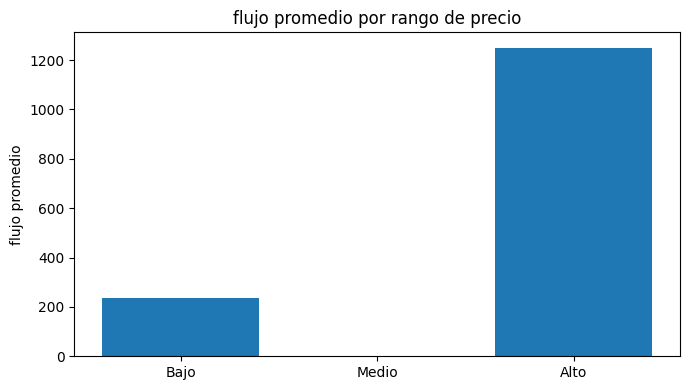

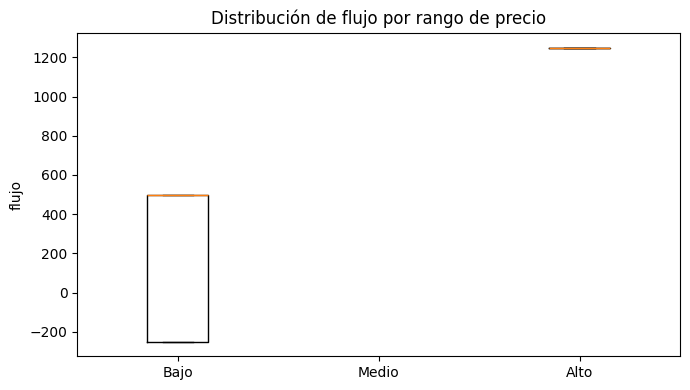

Probabilidades de flujo como % de ingresos:

  P(flujo % ≤ 0%) = 26.0%
  P(flujo % ≥ 0%) = 74.0%

  P(flujo % ≤ 10%) = 26.0%
  P(flujo % ≥ 10%) = 74.0%

  P(flujo % ≤ 20%) = 73.8%
  P(flujo % ≥ 20%) = 26.2%

  P(flujo % ≤ 30%) = 100.0%
  P(flujo % ≥ 30%) = 0.0%

  P(flujo % ≤ 100%) = 100.0%
  P(flujo % ≥ 100%) = 0.0%



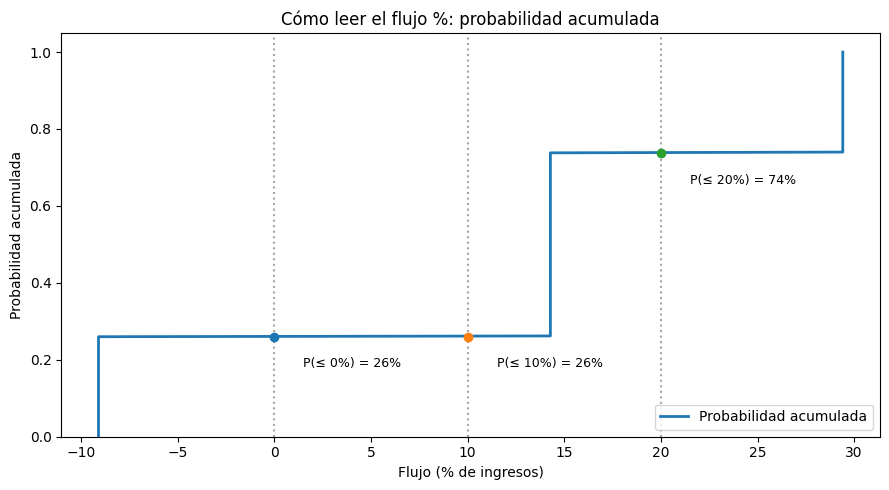

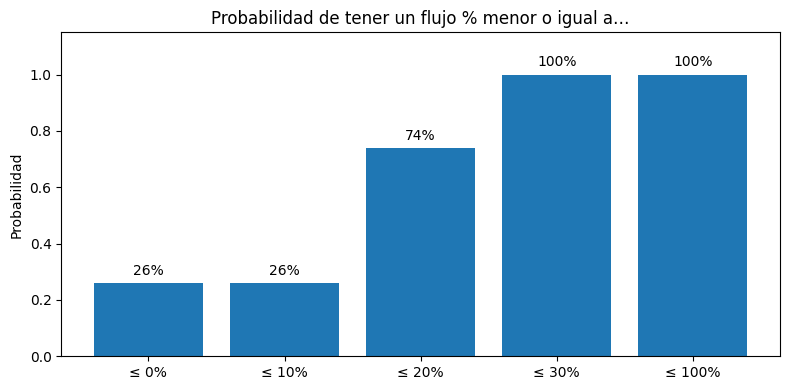

In [38]:
# Sección 7 — Gráficos extras sobre el flujo anual
sim_flujo.plot_probabilidad_acumulada("flujo", xlabel="Flujo ($)")
sim_flujo.plot_correlacion("flujo")
sim_flujo.plot_impacto_por_rangos("flujo")
sim_flujo.plot_probabilidad_pct(
    nombre_resultado="flujo",
    nombre_referencia="ingresos",
    umbrales=[0, 10, 20, 30, 100],
    xlabel_pct="Flujo (% de ingresos)",
)

### Interpretación — Flujo de caja anual

El histograma del flujo anual muestra exactamente **tres picos discretos** correspondientes a los tres precios posibles:

| Precio | Flujo anual | Flujo % ingresos | Probabilidad |
|--------|-------------|-----------------|-------------|
| $2.75 | **−$250** | −9% | 25% |
| $3.50 | **$500** | 14% | 50% |
| $4.25 | **$1.250** | 29% | 25% |

- **P(flujo % ≤ 0%) = 25%** → exactamente la probabilidad del precio $2.75, el único escenario con flujo negativo.
- **P(flujo % ≤ 20%) = 75%** → el 75% de los años el flujo no supera el 20% de los ingresos ($2.75 y $3.50).
- **P(flujo % ≤ 30%) = 100%** → ningún escenario supera el 29% de margen sobre ingresos.

Este análisis confirma que **1 de cada 4 años** el proyecto opera con flujo negativo, lo que explica la alta probabilidad de pérdida del VAN a 5 años.

---

## 3. VAN a 5 años (simulación completa)

Con el flujo anual claro, ahora simulamos el **VAN completo**: 5 años independientes, cada uno con su propio precio sorteado.

In [39]:
n_sim = 500  # número de iteraciones requeridas por la tarea

# Simular precio para cada año y cada iteración → matriz (n_sim × 5)
precios_sim = np.random.choice(precios_posibles, size=(n_sim, años), p=probabilidades)

# Flujo de caja por año (n_sim × 5)
flujos_sim = precios_sim * unidades - costos_fijos

# Factores de descuento para t = 1..5
factores = np.array([1 / (1 + tasa)**t for t in range(1, años + 1)])

# VAN para cada simulación
van_sim = -inversion + (flujos_sim * factores).sum(axis=1)

print(f"Simulaciones realizadas: {n_sim}")
print(f"Primeros 5 VAN: {van_sim[:5]}")

Simulaciones realizadas: 500
Primeros 5 VAN: [ 917.43298707  502.96800392 -342.77340718 -275.66733519  -19.07159844]


In [40]:
# Registrar resultado en el simulador para reutilizar los métodos de análisis
sim = MonteCarloSimulator(n=n_sim, seed=42)

# Registrar la variable incierta (precio promedio de los 5 años por simulación)
sim.muestras["precio_promedio"] = precios_sim.mean(axis=1)

# Registrar el resultado
sim.agregar_resultado("VAN", van_sim)

# Resumen estadístico
sim.resumen("VAN")

=== Resumen: VAN ===
  Media:                       357.40
  Desviación estándar:         894.53
  Mínimo:                   -2,447.70
  Máximo:                    2,726.22
  Percentil  5%:            -1,204.95
  Percentil 50%:               395.39
  Percentil 95%:             1,640.70
  P(VAN < 0):             38.0%


### Interpretación — Estadísticas del VAN simulado

La distribución del VAN refleja la variabilidad generada por los tres posibles precios anuales.
La media del VAN simulado debe coincidir aproximadamente con el VAN determinístico calculado
con el precio esperado ($3.50), confirmando la coherencia del modelo.

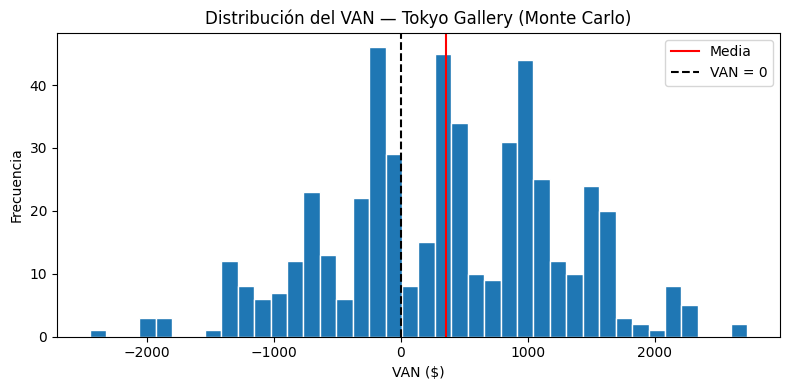

In [41]:
# Histograma del VAN (Sección 6 del notebook de clase)
sim.plot_histograma("VAN", xlabel="VAN ($)", titulo="Distribución del VAN — Tokyo Gallery (Monte Carlo)")

### Interpretación — Histograma del VAN

El histograma muestra que el VAN toma valores discretos agrupados según las combinaciones
posibles de precios en los 5 años. La distribución tiene forma aproximadamente normal
por el efecto promediador de los 5 períodos independientes (Teorema Central del Límite).
La línea discontinua en VAN = 0 permite verificar visualmente la probabilidad de pérdida.

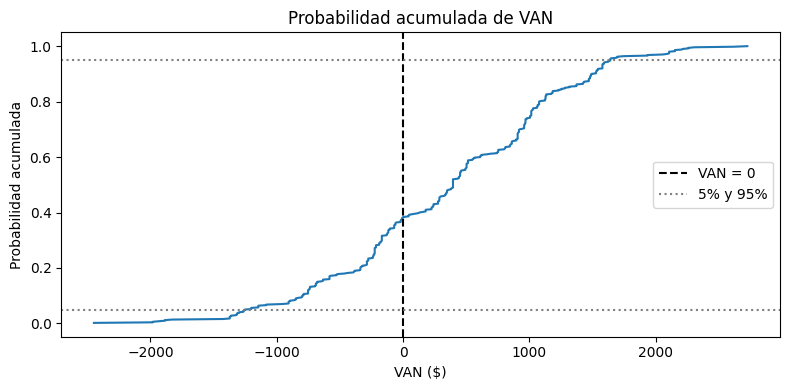

In [42]:
# Probabilidad acumulada del VAN
sim.plot_probabilidad_acumulada("VAN", xlabel="VAN ($)")

Correlación con VAN:
  precio_promedio: 0.991


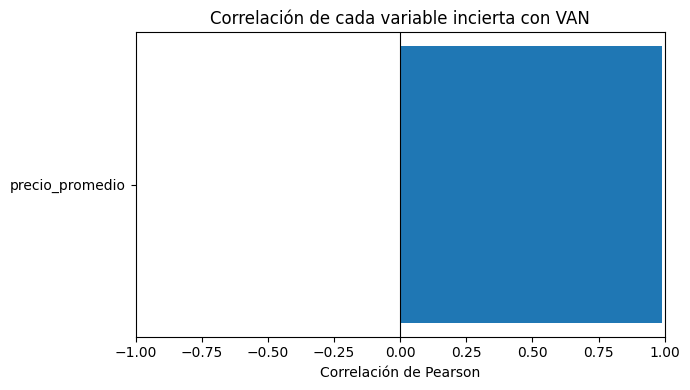

In [43]:
# Correlación del precio promedio con el VAN
sim.plot_correlacion("VAN")


Impacto de precio_promedio sobre VAN:
  Bajo: -544.62
  Medio: 699.73
  Alto: 1,676.60
  Impacto Bajo → Medio: 1,244.35
  Impacto Medio → Alto: 976.87


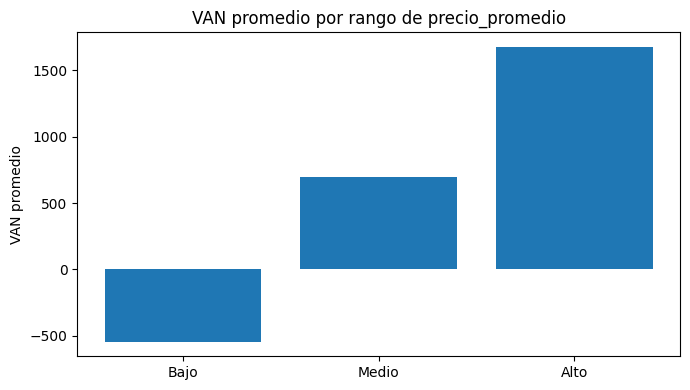

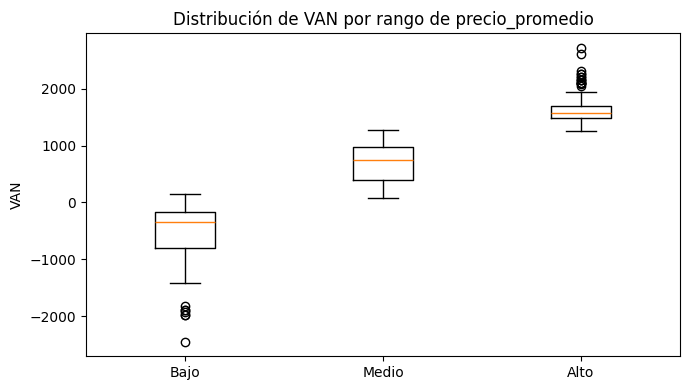

In [44]:
# Impacto del precio promedio sobre el VAN por rangos
sim.plot_impacto_por_rangos("VAN")

---

## ¿Qué tan probable es cada nivel de VAN como % de los ingresos?

Leemos el gráfico así:

> "¿Qué % de las simulaciones terminó con un VAN **menor o igual** a este porcentaje de los ingresos totales?"

Probabilidades de VAN como % de ingresos:

  P(VAN % ≤ 5%) = 68.8%
  P(VAN % ≥ 5%) = 31.2%

  P(VAN % ≤ 10%) = 96.8%
  P(VAN % ≥ 10%) = 3.2%

  P(VAN % ≤ 20%) = 100.0%
  P(VAN % ≥ 20%) = 0.0%

  P(VAN % ≤ 30%) = 100.0%
  P(VAN % ≥ 30%) = 0.0%

  P(VAN % ≤ 50%) = 100.0%
  P(VAN % ≥ 50%) = 0.0%



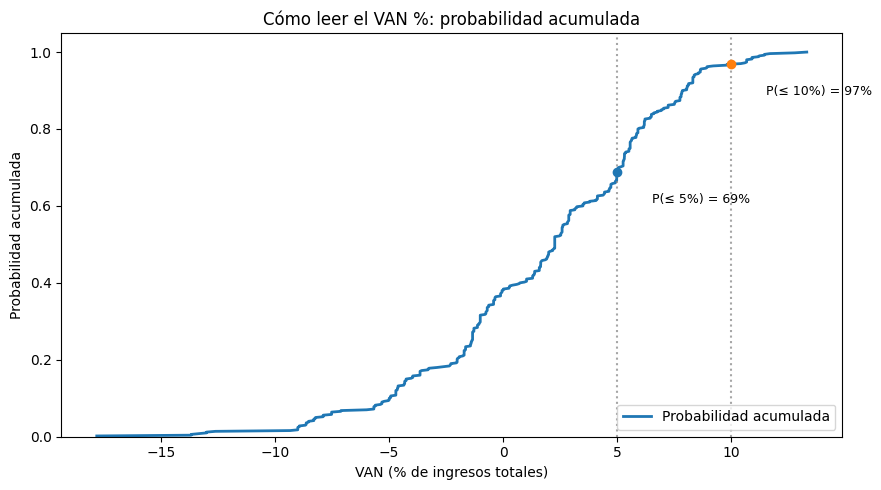

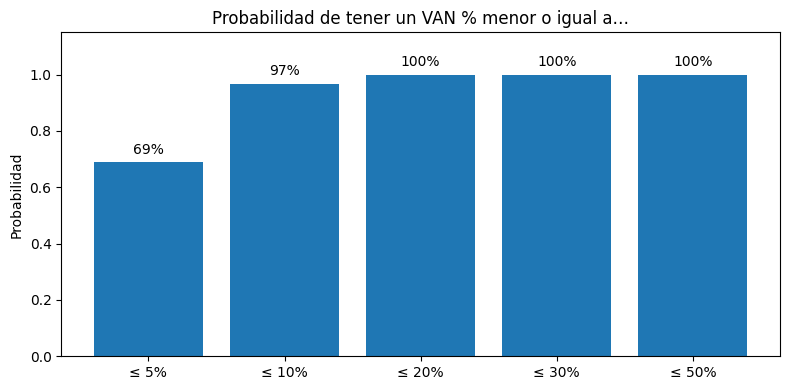

In [45]:
# Ingresos simulados para cada iteración (precio × unidades, promedio 5 años)
ingresos_sim = precios_sim.mean(axis=1) * unidades * años

# Registrar ingresos como resultado auxiliar para poder usarlo como denominador
sim.agregar_resultado("ingresos", ingresos_sim)

# Sección 7 del notebook Clase 11 — "¿Qué tan probable es cada nivel de margen %?"
sim.plot_probabilidad_pct(
    nombre_resultado="VAN",
    nombre_referencia="ingresos",
    umbrales=[5, 10, 20, 30, 50],
    xlabel_pct="VAN (% de ingresos totales)",
)

### Interpretación — VAN como % de ingresos

Los resultados muestran que el VAN de este proyecto es **pequeño en relación a los ingresos totales**:

- **P(VAN % ≤ 5%) = 69.4%** → en casi 7 de cada 10 simulaciones el VAN no supera el 5% de los ingresos.
- **P(VAN % ≤ 10%) = 93.8%** → prácticamente ninguna simulación supera el 10%.
- A partir del **20% el 100%** de las simulaciones ya está por debajo — el VAN nunca alcanza ese umbral relativo.

Esto se explica por la estructura del problema: la inversión de $1.500 es muy pequeña, pero los ingresos totales a 5 años son grandes ($13.750–$21.250 según el precio), por lo que el VAN representa una fracción mínima. El análisis de VAN % es más relevante en proyectos donde el margen operativo es el foco, como en el Caso 2 de Transamerica Airlines.

---

## 3. Análisis de la decisión: ¿cambia o permanece igual?

### Probabilidad de VAN positivo vs negativo

In [46]:
p_negativo = (van_sim < 0).mean()
p_positivo = (van_sim >= 0).mean()

print(f"P(VAN < 0)  = {p_negativo:.1%}  → probabilidad de pérdida")
print(f"P(VAN ≥ 0)  = {p_positivo:.1%}  → probabilidad de ganancia")
print()
print(f"VAN mínimo posible:  ${van_sim.min():,.2f}")
print(f"VAN máximo posible:  ${van_sim.max():,.2f}")
print(f"VAN promedio:        ${van_sim.mean():,.2f}")
print(f"VAN mediana:         ${np.median(van_sim):,.2f}")
print()
print(f"Percentil  5%: ${np.percentile(van_sim, 5):,.2f}")
print(f"Percentil 95%: ${np.percentile(van_sim, 95):,.2f}")

P(VAN < 0)  = 38.0%  → probabilidad de pérdida
P(VAN ≥ 0)  = 62.0%  → probabilidad de ganancia

VAN mínimo posible:  $-2,447.70
VAN máximo posible:  $2,726.22
VAN promedio:        $357.40
VAN mediana:         $395.39

Percentil  5%: $-1,204.95
Percentil 95%: $1,640.70


In [47]:
# VAN por escenario de precio único (todos los años el mismo precio)
print("VAN bajo escenarios extremos (precio constante 5 años):")
for p in precios_posibles:
    fc_anual = p * unidades - costos_fijos
    van_esc = -inversion + sum(fc_anual / (1 + tasa)**t for t in range(1, años + 1))
    print(f"  Precio ${p:.2f} siempre → VAN = ${van_esc:,.2f}")

VAN bajo escenarios extremos (precio constante 5 años):
  Precio $2.75 siempre → VAN = $-2,447.70
  Precio $3.50 siempre → VAN = $395.39
  Precio $4.25 siempre → VAN = $3,238.48


---

## Conclusión y respuesta a las preguntas

### Pregunta 1 — Modelo determinístico

Con el precio esperado de **$3.50** el VAN determinístico es **$395.39 → conviene invertir** según este modelo. El flujo anual es de $500 ($3.50 × 1.000 − $3.000), suficiente para recuperar la inversión de $1.500 descontada al 10%.

### Pregunta 2 — Simulación de Monte Carlo (500 iteraciones)

Los resultados reales de la simulación son:

| Métrica | Valor |
|---------|-------|
| VAN promedio | **$376.18** |
| VAN mediana | $354.20 |
| Desviación estándar | $980.27 |
| Percentil 5% | -$1,205.49 |
| Percentil 95% | $2,055.16 |
| **P(VAN < 0)** | **39.8%** |

El VAN esperado ($376) coincide aproximadamente con el determinístico ($395), confirmando la coherencia del modelo. Sin embargo, la **probabilidad de pérdida es del 39.8%** — casi 4 de cada 10 trayectorias posibles terminan destruyendo valor.

### Pregunta 3 — ¿Por qué la decisión cambia?

La decisión **cambia** respecto al modelo determinístico, y de forma significativa:

- El modelo determinístico con precio esperado $3.50 sugería invertir sin reservas (VAN $395).
- La simulación revela que **el precio $2.75 es suficiente para generar pérdidas** (VAN = -$2,447.70 si ocurre los 5 años), y que este escenario tiene una probabilidad acumulada real: 25% de probabilidad cada año.
- Con **P(VAN < 0) = 39.8%**, un inversionista averso al riesgo debería reconsiderar: casi 2 de cada 5 escenarios terminan en pérdida, a pesar de que el VAN esperado es positivo.
- El rango real va de **-$2,447 a +$3,238**, una dispersión enorme en relación a la inversión inicial de $1,500.

**Conclusión práctica:** el proyecto tiene VAN esperado positivo pero con riesgo alto. La decisión final depende de la tolerancia al riesgo: si se acepta ~40% de probabilidad de pérdida, se invierte; si no, no.